In [1]:

import jax.numpy as jnp

import sys

sys.path.append("../../siegel_analyses/scripts/")
sys.path.insert(1,'../scripts/')

import netrep_helpers as nh
import utils
import loader
import setup
import matplotlib.pyplot as plt

import seaborn as sns
%load_ext autoreload
%autoreload 2
import scipy.stats as sts
import numpy as np

import imp
imp.reload(setup)
imp.reload(loader)
imp.reload(utils)
import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

import matplotlib as mpl
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)

In [2]:
import pickle
with(open("1_fold_raw_behavior_all.pkl","rb")) as f:    
    cs_trials = pickle.load(f)


with open("1_folds_1_time_point_all.pkl","rb") as f:
    [params,train_data] = pickle.load(f)

In [3]:
def convert_to_rw_choices(cs_trials):
    choices = []
    for subject in cs_trials:
        left = subject[:,:4] == -1
        right = subject[:,5:] == 1
        both = np.column_stack([left.astype(int), right.astype(int)])
        choices.append(np.mean(both,0))
    return np.array(choices)

In [4]:
def get_dists_full(data):
    # Compute distance matrices for the full dataset without cv
    ys, cs = data
    S = len(ys)

    # Compute distance matrix
    dist_neural = utils.dsd([
        [ys[i], ys[j]]
        for i in range(S) 
        for j in range(S)]
    ).reshape(S, S)

    dist_cc = np.zeros((S, S))

    # Compute behavioral distance matrix
    for i in range(S):
        for j in range(S):
            dist_cc[i, j] = np.mean(np.abs(cs[i] - cs[j]))

    return dist_neural, dist_cc, cs

def get_kneigh_decreasing(dist_neural, cs, S=10, W=2):
    """
    Compute the correlation between each subject behavior and average of the top K=2 neighbors in neural space
    cs: list of behavioral functions for each subject
    dist_neural: distance matrix between subjects in neural space
    S: number of subjects
    W: number of neighbors to consider
    returns all_preds_top: (19, 20) S - 1 x S
    """

    avg_cc = np.array(cs)
    all_preds_top = []

    for K in range(W,S+1):
        preds_top = []
        for subj in range(S):
            subj_idx = list(range(S))

            # Ignore itself
            subj_idx.remove(subj)
            subj_idx = np.array(subj_idx)

            # Get distances from subj to all others
            dists = dist_neural[subj][subj_idx] 
            # Sort it (closest to furthest)
            sorted_idx = subj_idx[np.argsort(dists)]
            s_dists = np.sort(dists)
            weights_top = np.exp(-s_dists[K-W:K])

            # Extract the slice of K-W to K nearest neighbors
            top_k = avg_cc[sorted_idx[K-W:K]] 
            
            # Correlate subject behavior with average behavior of top K neighbors
            preds_top.append(sts.pearsonr(np.mean(top_k, 0), avg_cc[subj])[0])

        all_preds_top.append(preds_top)

    return np.array(all_preds_top)

In [5]:
n_shuffles = 100
corrs_shuffle = []

try: 
    dist_neural, dist_cc, cs = get_dists_full(train_data)
except np.linalg.LinAlgError:
    print("linalg error")

S = dist_neural.shape[0]

# Get upper triangle since its symetric
flat_dist_neural = dist_neural[np.triu_indices(S, 1)]
flat_dist_cc = dist_cc[np.triu_indices(S, 1)]

# correlation between neural and behavior distances 
r_true, p_true = sts.pearsonr(flat_dist_cc, flat_dist_neural)

# correlation between subject and closest neightbors behavior
S = dist_neural.shape[0]
preds_top = get_kneigh_decreasing(dist_neural, cs, S=S, W=2)

# compute shuffled correlation
flat_dist_cc_s = flat_dist_cc.copy()

for _ in tqdm.trange(n_shuffles):
    np.random.shuffle(flat_dist_cc_s)
    r_s, _ = sts.pearsonr(flat_dist_cc_s, flat_dist_neural)
    corrs_shuffle.append(r_s)

# save z-scored correlation 
# if r_true ~ r_suffle it means that the results that you got you could get indepentently of the supposition
z_score = (r_true - np.mean(corrs_shuffle)) / np.std(corrs_shuffle)

print(f"Correlation: {r_true}")
print(f"Correlation shuffle: {np.mean(corrs_shuffle)}")

print(f"z-Score: {z_score}")

2026-02-18 13:43:59,913	INFO worker.py:1998 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8266 
/Users/laurinemarty/miniconda3/envs/project/lib/python3.10/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
100%|██████████| 100/100 [00:00<00:00, 6999.49it/s]

Correlation: -0.0268518593439139
Correlation shuffle: 0.0006664785731430405
z-Score: -1.1565508373105167


(raylet) [2026-02-18 13:44:09,899 E 22618 732663] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-18_13-43-57_981939_21607 is over 95% full, available space: 9.11154 GB; capacity: 926.352 GB. Object creation will fail if spilling is required.
(raylet) [2026-02-18 13:44:19,978 E 22618 732663] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-18_13-43-57_981939_21607 is over 95% full, available space: 9.00296 GB; capacity: 926.352 GB. Object creation will fail if spilling is required.
(raylet) [2026-02-18 13:44:30,071 E 22618 732663] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-02-18_13-43-57_981939_21607 is over 95% full, available space: 9.00295 GB; capacity: 926.352 GB. Object creation will fail if spilling is required.


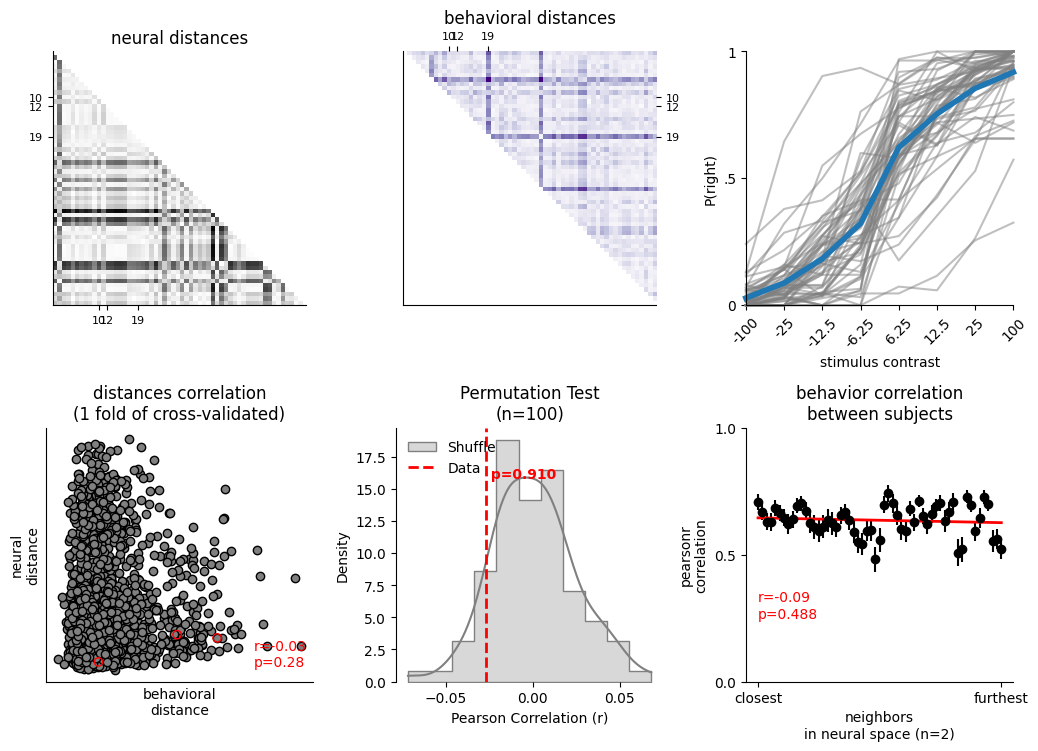

In [6]:
examples_idx= [10,12,19]
colors = np.array(sns.color_palette(None, S))

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7*1.5,5*1.5))

# Zero out part of matrix since symmetric
dist_neural_lower = dist_neural.copy()
dist_cc_upper = dist_cc.copy()
dist_neural_lower[np.triu_indices(dist_neural_lower.shape[0],0)] = np.nan
dist_cc_upper[np.tril_indices(dist_cc_upper.shape[0],0)] = np.nan

### DISTANCE MATRICES
axes = axes.flatten()
axes[0].set_title('neural distances')
axes[0].imshow(dist_neural_lower,cmap="Grays")
axes[0].set_xticks(examples_idx)
axes[0].set_yticks(examples_idx)


axes[1].set_title('behavioral distances')
axes[1].imshow(dist_cc_upper,cmap="Purples")
axes[1].set_xticks(examples_idx)
axes[1].set_yticks(examples_idx)
axes[1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False,left=False,labelleft=False,right=True,labelright=True)
#plt.colorbar(axes[1].imshow(dist_cc_,cmap="Purples"),ax=axes[1],shrink=0.5,orientation="horizontal")

#change ticks fontsize
for ti,tick in enumerate(axes[0].get_xticklabels()):
    tick.set_fontsize(8)
    axes[0].get_yticklabels()[ti].set_fontsize(8)
    axes[1].get_xticklabels()[ti].set_fontsize(8)
    axes[1].get_yticklabels()[ti].set_fontsize(8)


### PSYCHOMETRIC CURVES
contrast = [-100.  ,  -25.  ,  -12.5 ,   -6.25,    0.  ,    6.25,   12.5 ,
         25.  ,  100.  ]

avg_cc = [np.mean(c==1,0) for c in cs_trials]

choices = convert_to_rw_choices(cs_trials)
axes[2].plot(choices.T, color='gray', alpha=0.5,clip_on=False)
axes[2].plot(np.mean(choices,0), lw=4,clip_on=False)   
axes[2].set_ylabel("P(right)")
axes[2].set_xlabel("stimulus contrast")
axes[2].set_xticks(range(len(contrast)-1),[-100,-25,-12.5,-6.25,6.25,12.5,25,100],rotation=45)
axes[2].set_yticks([0,0.5,1],[0,'.5',1])
axes[2].set_ylim(0,1)
axes[2].set_xlim(0,7)

# take upper triangle
flat_dist_neural = dist_neural[jnp.triu_indices(S,1)]
flat_dist_cc = dist_cc[jnp.triu_indices(S,1)]


r,p = sts.pearsonr(flat_dist_cc,flat_dist_neural)
axes[3].scatter( flat_dist_cc,flat_dist_neural,color="k",facecolors='gray')
axes[3].text(1,0.1,"r={:.2f}\np={:.2f}".format(r,p),color="red")
axes[3].set_xlabel("behavioral\ndistance")
axes[3].set_ylabel("neural\ndistance")
axes[3].set_xticks([])
axes[3].set_yticks([])
axes[3].set_title("distances correlation\n(1 fold of cross-validated)")
axes[3].scatter(dist_cc[examples_idx,:][:,examples_idx][np.triu_indices(len(examples_idx),1)].flatten(),
                dist_neural[examples_idx,:][:,examples_idx][np.triu_indices(len(examples_idx),1)].flatten(),facecolors='none', edgecolors='red',zorder=10)


###

#
axes[4].set_title(f"Permutation Test\n(n={len(corrs_shuffle)})")

# null distribution
sns.histplot(corrs_shuffle, color="gray", kde=True, ax=axes[4], stat='density', element="step", alpha=0.3, label='Shuffle')

# Plot real data line
axes[4].axvline(r_true, color='red', linestyle='--', linewidth=2, label='Data')

# p value : the amount of suffled corr that have r greated than r_true
p_val = np.mean(np.array(corrs_shuffle) >= r_true)
axes[4].text(r_true, axes[4].get_ylim()[1]*0.8, f" p={p_val:.3f}", color='red', fontweight='bold')

axes[4].set_xlabel("Pearson Correlation (r)")
axes[4].set_ylabel("Density")
axes[4].legend(loc='upper left', frameon=False)
sns.despine(ax=axes[4])

###


# Neighborhood correlation 
#_ids = list(range(S-1))*np.shape(preds_top)[0]
num_neighbors_steps = preds_top.shape[0]
_ids = range(num_neighbors_steps)
y_mean = np.mean(preds_top, axis=1)
y_std = np.std(preds_top, axis=1) / np.sqrt(S)

r=sts.linregress(_ids,y_mean)
num_sess = dist_neural.shape[0]-1

#axes[5].plot(np.mean(all_preds_top,2).T,"k.",alpha=0.1,clip_on=False)
plt.errorbar(_ids,y_mean,y_std,fmt='o',color='black',clip_on=False)
#axes[5].plot(np.mean(all_preds_top,2).mean(0),"r-",lw=2)
axes[5].set_title("behavior correlation\nbetween subjects")

axes[5].text(0,0.25,"r={:.2f}\np={:.3f}".format(r.rvalue,r.pvalue),color='r')  
axes[5].set_ylabel("pearsonr\ncorrelation")
axes[5].set_yticks([0,0.5,1])
#axes[5].set_xticks([0,(S-2)//2,S-2],["closest","[%i,%i]" % ((S-2)//2,(S-2)//2+1),"[%i,%i]" % (S-2,S-1)])
axes[5].set_xticks([0,S-2],["closest","furthest"])

axes[5].set_xlabel("neighbors\nin neural space (n=2)")
#axes[5].hlines(y=0.8, xmin=0, xmax=18, colors='black',lw=0.5)
axes[5].set_ylim(0,1)
#axes[5].text(9,.95,"*",color='black')
# plot regression line on top of the data using the slope and intercept
axes[5].plot(range(num_sess)*r.slope+r.intercept,"r-",lw=2)

fig.tight_layout()
sns.despine()
sns.despine(ax=axes[4],bottom=True)


#plt.savefig("../results_web_new/IBL_main_figure.svg",dpi=300)